In [1]:
import platform
platform.platform()

'macOS-26.2-arm64-arm-64bit'

In [2]:
import sys
sys.version

'3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]'

In [3]:
import os
sys.path.append(os.path.abspath("../../.."))

In [4]:
import matplotlib
matplotlib.__version__

'3.10.8'

In [5]:
import matplotlib.pyplot as plt

In [6]:
import numpy as np
np.__version__

'1.23.5'

In [7]:
import pandas as pd
pd.__version__

'2.3.3'

In [8]:
from rdkit import rdBase
rdBase.rdkitVersion

'2023.09.1'

In [9]:
import scipy
scipy.__version__

'1.15.3'

In [10]:
import sklearn
sklearn.__version__

'1.3.0'

In [11]:
from sklearn.decomposition import PCA

In [12]:
from SSMetrics import metrics, ecfp

In [13]:
df1 = pd.read_csv("../../../1_dataset/4_ECFP/1_PCA/ecfp_pca.csv")
df1.shape

(4665, 9)

In [14]:
df1.columns

Index(['InChI', 'K3FeCN6', 'MesAcr+BF4-', 'CuCl', 'Diacetyl', 'T(p-OMe)PPCo',
       'Electrode', 'PC1', 'PC2'],
      dtype='object')

In [15]:
conditions = [["K3FeCN6",(255/255, 75/255, 0/255), "K$_3$[Fe(CN)$_6$]"],
              ["MesAcr+BF4-", (153/255, 0/255, 153/255), "MesAcr$^+$BF$_4^-$"],
              ["CuCl", (3/255, 175/255, 122/255), "CuCl"],
              ["Diacetyl", (246/255, 170/255, 0/255), "Diacetyl"],
              ["T(p-OMe)PPCo", (77/255, 196/255, 255/255), "T($p$-OMe)PPCo"],
              ["Electrode", (255/255, 128/255, 130/255), "Electrode"]]

In [16]:
li_numbers = []
li_2_2048 = []

li_ratio1 = [10.930339888320555]

li_2_4096 = []
li_3_2048 = []
li_3_4096 = []
li_4_2048 = []
li_4_4096 = []

In [17]:
for i in range(6):
    condition = conditions[i][0]
    print(df1[condition].value_counts())

    df2 = df1[df1[condition] == 1].loc[:, "PC1":"PC2"]
    li_numbers.append(len(df2))

    array2 = df2.to_numpy()

    area, _ = metrics.metrics_ConvexHull(array2)
    li_2_2048.append(area)

    print(f"ECFP ConvexHull: {area}\n")

K3FeCN6
 0    4591
-1      51
 1      23
Name: count, dtype: int64
ECFP ConvexHull: 5.269410299306606

MesAcr+BF4-
0    4645
1      20
Name: count, dtype: int64
ECFP ConvexHull: 3.8684899103842296

CuCl
0    4646
1      19
Name: count, dtype: int64
ECFP ConvexHull: 3.3331839098431084

Diacetyl
0    4653
1      12
Name: count, dtype: int64
ECFP ConvexHull: 3.3326575272657646

T(p-OMe)PPCo
0    4656
1       9
Name: count, dtype: int64
ECFP ConvexHull: 5.920380085153649

Electrode
0    4656
1       9
Name: count, dtype: int64
ECFP ConvexHull: 3.5626385860785366



In [18]:
def calc(li, radius, nBits):
    df_ecfp = ecfp(df1["InChI"], radius, nBits)

    pca = PCA(n_components=2, whiten=True)
    pca.fit(df_ecfp)

    df_score = pd.DataFrame(pca.transform(df_ecfp), columns=["PC1", "PC2"])
    df_pca = pd.concat([df1.loc[:, "InChI":"Electrode"], df_score], axis=1)

    ratio = pca.explained_variance_ratio_
    li_ratio1.append((ratio[0] + ratio[1])*100)
    
    for i in range(6):
        condition = conditions[i][0]
        print(f"{condition}, {radius}, {nBits}")
        
        df = df_pca[df_pca[condition] == 1].loc[:, "PC1":"PC2"]
        array = df.to_numpy()

        area, _ = metrics.metrics_ConvexHull(array)
        li.append(area)

        print(f"ECFP ConvexHull: {area}\n")

In [19]:
calc(li_2_4096, 2, 4096)
calc(li_3_2048, 3, 2048)
calc(li_3_4096, 3, 4096)
calc(li_4_2048, 4, 2048)
calc(li_4_4096, 4, 4096)

K3FeCN6, 2, 4096
ECFP ConvexHull: 5.336413574077548

MesAcr+BF4-, 2, 4096
ECFP ConvexHull: 3.892705768204301

CuCl, 2, 4096
ECFP ConvexHull: 3.08795903990072

Diacetyl, 2, 4096
ECFP ConvexHull: 3.06533072199398

T(p-OMe)PPCo, 2, 4096
ECFP ConvexHull: 5.826478551359162

Electrode, 2, 4096
ECFP ConvexHull: 3.2680604558416726

K3FeCN6, 3, 2048
ECFP ConvexHull: 4.422251771838256

MesAcr+BF4-, 3, 2048
ECFP ConvexHull: 3.354800460205858

CuCl, 3, 2048
ECFP ConvexHull: 2.6212987325364274

Diacetyl, 3, 2048
ECFP ConvexHull: 2.807453819798233

T(p-OMe)PPCo, 3, 2048
ECFP ConvexHull: 4.625098145255403

Electrode, 3, 2048
ECFP ConvexHull: 3.156734078070848

K3FeCN6, 3, 4096
ECFP ConvexHull: 4.203194267476419

MesAcr+BF4-, 3, 4096
ECFP ConvexHull: 3.277037997266661

CuCl, 3, 4096
ECFP ConvexHull: 2.411843945992472

Diacetyl, 3, 4096
ECFP ConvexHull: 2.5491878495686793

T(p-OMe)PPCo, 3, 4096
ECFP ConvexHull: 4.028061314760687

Electrode, 3, 4096
ECFP ConvexHull: 2.8075768370370304

K3FeCN6, 4, 2048


In [20]:
labels = []

for i in range(6):
    labels.append(f"{conditions[i][2]} ({li_numbers[i]})")
    
labels

['K$_3$[Fe(CN)$_6$] (23)',
 'MesAcr$^+$BF$_4^-$ (20)',
 'CuCl (19)',
 'Diacetyl (12)',
 'T($p$-OMe)PPCo (9)',
 'Electrode (9)']

In [21]:
df_result1 = pd.DataFrame({"Condition": [e[0] for e in conditions],
                           "Number":li_numbers})

df_result1[f"radius=2,\nnBits=2048\n({li_ratio1[0]:.2f}%)"] = li_2_2048
df_result1[f"radius=2,\nnBits=4096\n({li_ratio1[1]:.2f}%)"] = li_2_4096
df_result1[f"radius=3,\nnBits=2048\n({li_ratio1[2]:.2f}%)"] = li_3_2048
df_result1[f"radius=3,\nnBits=4096\n({li_ratio1[3]:.2f}%)"] = li_3_4096
df_result1[f"radius=4,\nnBits=2048\n({li_ratio1[4]:.2f}%)"] = li_4_2048
df_result1[f"radius=4,\nnBits=4096\n({li_ratio1[5]:.2f}%)"] = li_4_4096

df_result1

,Condition,Number,"radius=2,\nnBits=2048\n(10.93%)","radius=2,\nnBits=4096\n(10.86%)","radius=3,\nnBits=2048\n(8.64%)","radius=3,\nnBits=4096\n(8.67%)","radius=4,\nnBits=2048\n(7.56%)","radius=4,\nnBits=4096\n(7.60%)"
0,K3FeCN6,23,5.269410,5.336414,4.422252,4.203194,4.166690,3.968090
1,MesAcr+BF4-,20,3.868490,3.892706,3.354800,3.277038,3.311097,3.162739
2,CuCl,19,3.333184,3.087959,2.621299,2.411844,2.559570,2.307918
3,Diacetyl,12,3.332658,3.065331,2.807454,2.549188,2.820822,2.489087
4,T(p-OMe)PPCo,9,5.920380,5.826479,4.625098,4.028061,4.277245,3.691856
5,Electrode,9,3.562639,3.268060,3.156734,2.807577,3.067136,2.636875


In [22]:
df_result1.to_csv("si_ecfp_ConvexHull_1.csv", index=False)

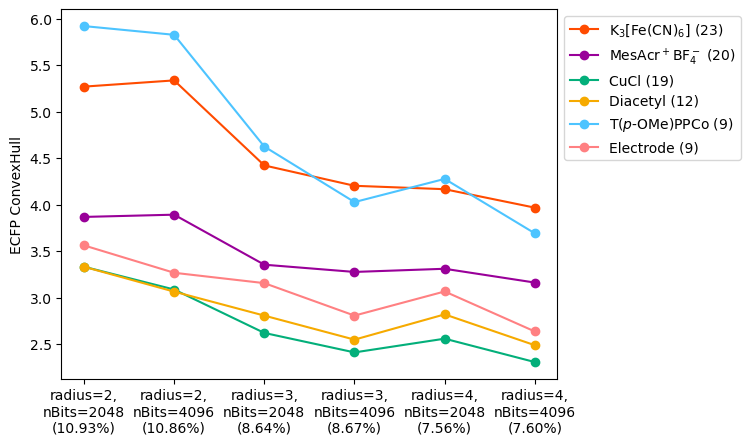

In [23]:
fig = plt.figure()
ax = fig.add_subplot()

for i in range(6):
    ax.plot(
        df_result1.iloc[i, 2:],
        marker="o",
        color=conditions[i][1],
        label=labels[i]
        )

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.set_ylabel("ECFP ConvexHull")

plt.savefig("si_ecfp_ConvexHull_1.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
li_ratio2 = [10.930339888320555]

li_3d = []
li_4d = []
li_5d = []
li_6d = []
li_7d = []
li_8d = []


In [25]:
df_ecfp = ecfp(df1["InChI"], 2, 2048)

In [26]:
def calc_d(li, n_components):
    pca = PCA(n_components=n_components, whiten=True)
    pca.fit(df_ecfp)

    df_score = pd.DataFrame(
        pca.transform(df_ecfp),
        columns=[f"PC{i}" for i in range(1, n_components+1)]
        )
    df_pca = pd.concat([df1.loc[:, "InChI":"Electrode"], df_score], axis=1)

    ratio = pca.explained_variance_ratio_
    ans = 0
    for i in range(n_components):
        ans += ratio[i]
    li_ratio2.append(ans*100)

    for i in range(6):
        condition = conditions[i][0]
        print(f"{condition}, {n_components}D")

        df = df_pca[df_pca[condition] == 1].loc[:, "PC1":f"PC{n_components}"]
        array = df.to_numpy()

        area, _ = metrics.metrics_ConvexHull(array)
        li.append(area)

        print(f"ECFP ConvexHull: {area}\n")
    

In [27]:
calc_d(li_3d, 3)
calc_d(li_4d, 4)
calc_d(li_5d, 5)
calc_d(li_6d, 6)
calc_d(li_7d, 7)
calc_d(li_8d, 8)

K3FeCN6, 3D
ECFP ConvexHull: 8.43184879605475

MesAcr+BF4-, 3D
ECFP ConvexHull: 4.099112402567368

CuCl, 3D
ECFP ConvexHull: 1.4902978542440408

Diacetyl, 3D
ECFP ConvexHull: 1.4212184578310996

T(p-OMe)PPCo, 3D
ECFP ConvexHull: 8.11829506640206

Electrode, 3D
ECFP ConvexHull: 1.403393930325285

K3FeCN6, 4D
ECFP ConvexHull: 9.405614881513921

MesAcr+BF4-, 4D
ECFP ConvexHull: 1.8537602089047298

CuCl, 4D
ECFP ConvexHull: 0.5070702545975113

Diacetyl, 4D
ECFP ConvexHull: 0.48459507618159064

T(p-OMe)PPCo, 4D
ECFP ConvexHull: 3.6874743234253287

Electrode, 4D
ECFP ConvexHull: 0.5208942905384425

K3FeCN6, 5D
ECFP ConvexHull: 2.7752092109157993

MesAcr+BF4-, 5D
ECFP ConvexHull: 0.7706208633194935

CuCl, 5D
ECFP ConvexHull: 0.14091380876052947

Diacetyl, 5D
ECFP ConvexHull: 0.10276133245996925

T(p-OMe)PPCo, 5D
ECFP ConvexHull: 0.8820608180114116

Electrode, 5D
ECFP ConvexHull: 0.10131454671757724

K3FeCN6, 6D
ECFP ConvexHull: 1.1348840784373473

MesAcr+BF4-, 6D
ECFP ConvexHull: 0.1980532907

In [28]:
df_result2 = pd.DataFrame({"Condition": [e[0] for e in conditions],
                           "Number":li_numbers})

df_result2[f"2\n({li_ratio2[0]:.2f}%)"] = li_2_2048
df_result2[f"3\n({li_ratio2[1]:.2f}%)"] = li_3d
df_result2[f"4\n({li_ratio2[2]:.2f}%)"] = li_4d
df_result2[f"5\n({li_ratio2[3]:.2f}%)"] = li_5d
df_result2[f"6\n({li_ratio2[4]:.2f}%)"] = li_6d
df_result2[f"7\n({li_ratio2[5]:.2f}%)"] = li_7d
df_result2[f"8\n({li_ratio2[6]:.2f}%)"] = li_8d


df_result2

,Condition,Number,2\n(10.93%),3\n(14.96%),4\n(17.80%),5\n(20.48%),6\n(22.86%),7\n(24.93%),8\n(26.94%)
0,K3FeCN6,23,5.269410,8.431849,9.405615,2.775209,1.134884,0.325336,0.058879
1,MesAcr+BF4-,20,3.868490,4.099112,1.853760,0.770621,0.198053,0.028550,0.002019
2,CuCl,19,3.333184,1.490298,0.507070,0.140914,0.024121,0.002830,0.000159
3,Diacetyl,12,3.332658,1.421218,0.484595,0.102761,0.016188,0.001029,0.000028
4,T(p-OMe)PPCo,9,5.920380,8.118295,3.687474,0.882061,0.151312,0.008731,0.000193
5,Electrode,9,3.562639,1.403394,0.520894,0.101315,0.016292,0.001768,0.000176


In [29]:
df_result2.to_csv("si_ecfp_ConvexHull_2.csv", index=False)

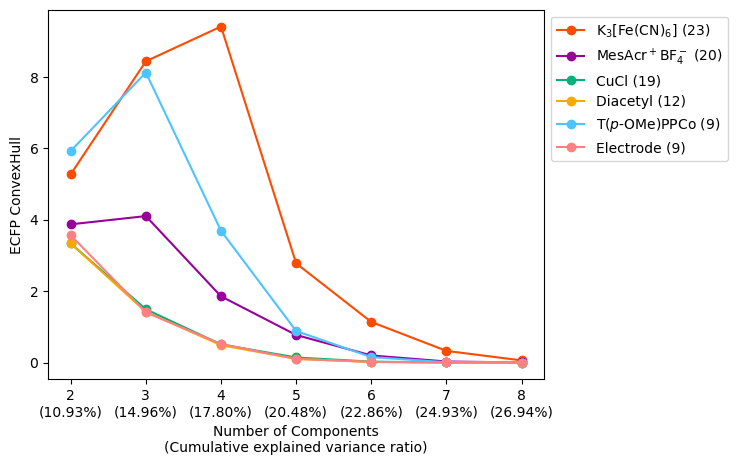

In [30]:
fig = plt.figure()
ax = fig.add_subplot()

for i in range(6):
    ax.plot(
        df_result2.iloc[i, 2:],
        marker="o",
        color=conditions[i][1],
        label=labels[i]
        )

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.set_xlabel("Number of Components\n(Cumulative explained variance ratio)")
ax.set_ylabel("ECFP ConvexHull")

plt.savefig("si_ecfp_ConvexHull_2.png", dpi=300, bbox_inches="tight")
plt.show()